<a href="https://colab.research.google.com/github/fralfaro/ICS40125/blob/main/docs/labs/lab_07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ICS40125 - Laboratorio N°07

**Objetivo**: Aplicar técnicas básicas de **Machine Learning** (tanto regresión como clasificación), desde la preparación de datos hasta el entrenamiento y evaluación de modelos.

> **Nota**: Puede ayudarse de algún asistente virtual como **ChatGPT, Gemini** u otros, así como del autocompletado de **Google Colab**, para avanzar en este laboratorio debido a su extensión.



## Regresión


<img src="https://cdn-icons-png.flaticon.com/512/2400/2400362.png" width = "300" align="center"/>


Los datos utilizados corresponden a propiedades localizadas en un distrito específico de California, junto con algunas estadísticas resumen extraídas del censo de 1990. Es importante tener en cuenta que los datos no han sido procesados previamente, por lo que será necesario realizar algunas etapas de limpieza y preprocesamiento.

Las columnas incluidas en el conjunto de datos son las siguientes (sus nombres son descriptivos):

* **longitude**: Longitud geográfica de la propiedad.
* **latitude**: Latitud geográfica de la propiedad.
* **housingmedianage**: Edad media de las viviendas en la zona.
* **total_rooms**: Número total de habitaciones.
* **total_bedrooms**: Número total de dormitorios.
* **population**: Población en el área circundante.
* **households**: Número de hogares en la zona.
* **median_income**: Ingreso medio por hogar.
* **medianhousevalue**: Valor medio de la propiedad.
* **ocean_proximity**: Proximidad al océano.

El objetivo de este análisis es predecir el valor medio de las propiedades utilizando las características proporcionadas.

Para completar este laboratorio, se recomienda seguir la siguiente rúbrica de trabajo:

1. **Definición del problema**: Clarificar el objetivo del análisis y los resultados esperados.
2. **Estadística descriptiva**: Resumir las principales características de los datos a través de medidas estadísticas.
3. **Visualización descriptiva**: Utilizar gráficos para explorar los datos y sus relaciones.
4. **Preprocesamiento**: Realizar los pasos necesarios de limpieza y transformación de los datos.
5. **Selección de modelo**: Comparar al menos cuatro modelos de predicción diferentes.
6. **Métricas y análisis de resultados**: Evaluar el rendimiento de los modelos utilizando métricas apropiadas.
7. **Visualización de resultados del modelo**: Crear gráficos que muestren el desempeño de los modelos.
8. **Conclusiones**: Resumir los hallazgos del análisis.

> **Nota**: Se anima a los estudiantes a desarrollar un análisis más profundo si lo desean. Pueden consultar como referencia el siguiente [enlace](https://www.kaggle.com/camnugent/california-housing-prices).

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def regression_metrics(df):
    """
    Aplicar las distintas métricas definidas
    :param df: DataFrame con las columnas: ['y', 'yhat']
    :return: DataFrame con las métricas especificadas
    """
    df_result = pd.DataFrame()

    y_true = df['y']
    y_pred = df['yhat']

    df_result['mae'] = [round(mean_absolute_error(y_true, y_pred), 4)]
    df_result['mse'] = [round(mean_squared_error(y_true, y_pred), 4)]
    df_result['rmse'] = [round(np.sqrt(mean_squared_error(y_true, y_pred)), 4)]
    df_result['mape'] = [round(mean_absolute_percentage_error(y_true, y_pred), 4)]
    df_result['smape'] = [round(2 * mean_absolute_percentage_error(y_true, y_pred) / (mean_absolute_percentage_error(y_true, y_pred) + 100), 4)]

    return df_result

In [6]:
from sklearn.datasets import fetch_california_housing

# Cargar los datos de housing
housing_data = fetch_california_housing(as_frame=True)

# Convertir los datos en un DataFrame de pandas
housing = housing_data['data']
housing['target'] = housing_data['target']

# Visualizar las primeras filas del DataFrame
housing.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


Resumen Estadístico del Dataset:
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude        target  
count  20640.000000  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861   -119.569704      2.068558  
std       10.386050      2.135952      2.003532      1.153956  

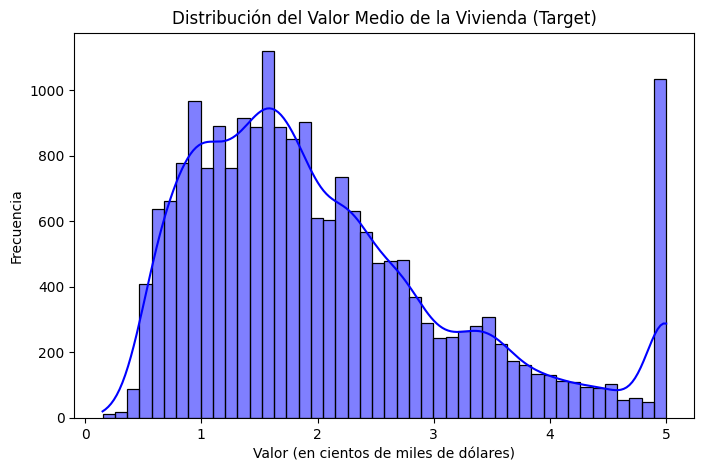

--------------------------------------------------


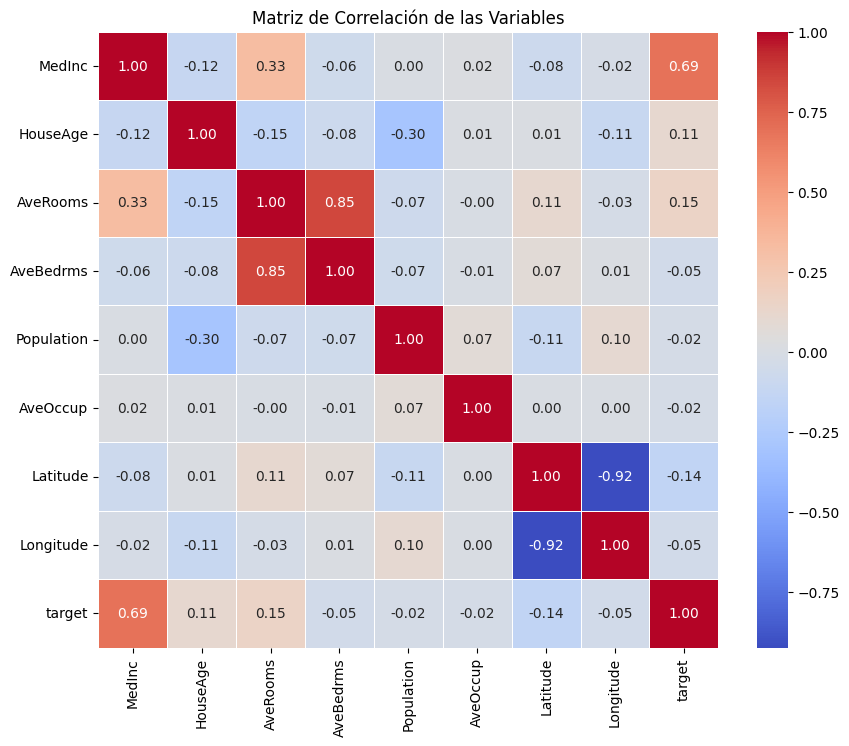

--------------------------------------------------
Preprocesamiento completado exitosamente:
Tamaño de X_train: (16512, 8)
Tamaño de X_test: (4128, 8)
--------------------------------------------------


In [7]:
# =====================================================================
# 2. Estadística descriptiva
# =====================================================================
# Obtener un resumen estadístico de todas las variables (media, desvío, min, max)
print("Resumen Estadístico del Dataset:")
print(housing.describe())
print("-" * 50)

# Verificar la presencia de valores nulos por columna
print("Cantidad de Valores Nulos por Columna:")
print(housing.isnull().sum())
print("-" * 50)


# =====================================================================
# 3. Visualización descriptiva
# =====================================================================
# Histograma de la variable objetivo ('target' representa el valor medio de la casa)
plt.figure(figsize=(8, 5))
sns.histplot(housing['target'], kde=True, color='blue')
plt.title('Distribución del Valor Medio de la Vivienda (Target)')
plt.xlabel('Valor (en cientos de miles de dólares)')
plt.ylabel('Frecuencia')
plt.show()
print("-" * 50)

# Matriz de correlación para evaluar la relación entre variables
plt.figure(figsize=(10, 8))
sns.heatmap(housing.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación de las Variables')
plt.show()
print("-" * 50)


# =====================================================================
# 4. Preprocesamiento (División del dataset y Escalado)
# =====================================================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separar características (X) y la variable objetivo (y)
X = housing.drop(columns=['target'])
y = housing['target']

# Dividir el conjunto de datos en Entrenamiento (80%) y Testeo (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Escalar las características (StandardScaler resta la media y divide por el desvío estándar)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Preprocesamiento completado exitosamente:")
print(f"Tamaño de X_train: {X_train_scaled.shape}")
print(f"Tamaño de X_test: {X_test_scaled.shape}")
print("-" * 50)

## Clasificación


<img src="https://miro.medium.com/v2/resize:fit:372/0*EwdH1C6ThmpwY0Qo.png" width = "400" align="center"/>

El objetivo de este proyecto es realizar la mejor predicción posible de las imágenes a partir de los datos disponibles. Para lograrlo, es necesario seguir los pasos habituales en un proyecto de _Machine Learning_, que incluyen la exploración estadística, la visualización y el preprocesamiento de los datos.

Se solicita lo siguiente:

* Ajustar al menos tres modelos de clasificación:
    * Regresión logística.
    * K-Nearest Neighbors.
    * Un algoritmo adicional o más, de libre elección. Puedes consultar [esta lista de algoritmos](https://scikit-learn.org/stable/supervised_learning.html#supervised-learning) para obtener ideas.
  
* Realizar predicciones con cada uno de los tres modelos utilizando el conjunto de datos de _test_ y calcular sus respectivas puntuaciones (_score_).

* Evaluar y analizar los resultados de los modelos utilizando las siguientes métricas de rendimiento:
    * **Accuracy**
    * **Precision**
    * **Recall**
    * **F1-score**

### Exploración de los datos
A continuación se carga el conjunto de datos a utilizar, a través del sub-módulo `datasets` de `sklearn`.

In [8]:
import numpy as np
import pandas as pd
from sklearn import datasets
import matplotlib.pyplot as plt

%matplotlib inline

In [9]:
digits_dict = datasets.load_digits()
print(digits_dict["DESCR"])

.. _digits_dataset:

Optical recognition of handwritten digits dataset
--------------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 1797
:Number of Attributes: 64
:Attribute Information: 8x8 image of integer pixels in the range 0..16.
:Missing Attribute Values: None
:Creator: E. Alpaydin (alpaydin '@' boun.edu.tr)
:Date: July; 1998

This is a copy of the test set of the UCI ML hand-written digits datasets
https://archive.ics.uci.edu/ml/datasets/Optical+Recognition+of+Handwritten+Digits

The data set contains images of hand-written digits: 10 classes where
each class refers to a digit.

Preprocessing programs made available by NIST were used to extract
normalized bitmaps of handwritten digits from a preprinted form. From a
total of 43 people, 30 contributed to the training set and different 13
to the test set. 32x32 bitmaps are divided into nonoverlapping blocks of
4x4 and the number of on pixels are counted in each block. This generates
an in

In [10]:
# informacion de las columnas
digits_dict.keys()

dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])

In [11]:
# informacion del target
digits_dict["target"]

array([0, 1, 2, ..., 8, 9, 8])

A continuación se crea dataframe declarado como `digits` con los datos de `digits_dict` tal que tenga 65 columnas, las 6 primeras a la representación de la imagen en escala de grises (0-blanco, 255-negro) y la última correspondiente al dígito (`target`) con el nombre _target_.

In [12]:
# leer datos
digits = (
    pd.DataFrame(
        digits_dict["data"],
    )
    .rename(columns=lambda x: f"c{x:02d}")
    .assign(target=digits_dict["target"])
    .astype(int)
)

digits.head()

,c00,c01,c02,c03,c04,c05,c06,c07,c08,c09,...,c55,c56,c57,c58,c59,c60,c61,c62,c63,target
0,0,0,5,13,9,1,0,0,0,0,...,0,0,0,6,13,10,0,0,0,0
1,0,0,0,12,13,5,0,0,0,0,...,0,0,0,0,11,16,10,0,0,1
2,0,0,0,4,15,12,0,0,0,0,...,0,0,0,0,3,11,16,9,0,2
3,0,0,7,15,13,1,0,0,0,8,...,0,0,0,7,13,13,9,0,0,3
4,0,0,0,1,11,0,0,0,0,0,...,0,0,0,0,2,16,4,0,0,4


### Ejercicio 1
**Análisis exploratorio:** Realiza tu análisis exploratorio, no debes olvidar nada! Recuerda, cada análisis debe responder una pregunta.

Algunas sugerencias:

* ¿Cómo se distribuyen los datos?
* ¿Cuánta memoria estoy utilizando?
* ¿Qué tipo de datos son?
* ¿Cuántos registros por clase hay?
* ¿Hay registros que no se correspondan con tu conocimiento previo de los datos?

In [13]:
# =====================================================================
# Ejercicio 1: Análisis exploratorio de datos (digits)
# =====================================================================

# 1. ¿Qué tipo de datos son y cuánta memoria estoy utilizando?
print("Información General del Dataset (Tipos de datos y memoria):")
print(digits.info())
print("-" * 50)


# 2. ¿Cómo se distribuyen los datos? (Resumen estadístico básico de los píxeles)
print("Resumen Estadístico General de las Características (Píxeles):")
print(digits.describe())
print("-" * 50)


# 3. ¿Cuántos registros por clase hay? (Distribución de los dígitos del 0 al 9)
print("Cantidad de Registros por Clase (Dígito de Target):")
registros_por_clase = digits['target'].value_counts().sort_index()
print(registros_por_clase)
print("-" * 50)


# 4. ¿Hay registros que no se correspondan con tu conocimiento previo?
# Verificamos los valores mínimos y máximos globales permitidos en la matriz de píxeles
print("Verificación de límites en los datos:")
pixel_min = digits.drop(columns=['target']).min().min()
pixel_max = digits.drop(columns=['target']).max().max()
print(f"Valor mínimo de píxel encontrado: {pixel_min}")
print(f"Valor máximo de píxel encontrado: {pixel_max}")

# Verificamos que las clases del target sean únicamente los dígitos del 0 al 9
clases_unicas = digits['target'].unique()
print(f"Clases únicas detectadas en 'target': {sorted(clases_unicas)}")
print("-" * 50)

Información General del Dataset (Tipos de datos y memoria):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1797 entries, 0 to 1796
Data columns (total 65 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   c00     1797 non-null   int64
 1   c01     1797 non-null   int64
 2   c02     1797 non-null   int64
 3   c03     1797 non-null   int64
 4   c04     1797 non-null   int64
 5   c05     1797 non-null   int64
 6   c06     1797 non-null   int64
 7   c07     1797 non-null   int64
 8   c08     1797 non-null   int64
 9   c09     1797 non-null   int64
 10  c10     1797 non-null   int64
 11  c11     1797 non-null   int64
 12  c12     1797 non-null   int64
 13  c13     1797 non-null   int64
 14  c14     1797 non-null   int64
 15  c15     1797 non-null   int64
 16  c16     1797 non-null   int64
 17  c17     1797 non-null   int64
 18  c18     1797 non-null   int64
 19  c19     1797 non-null   int64
 20  c20     1797 non-null   int64
 21  c21     1797 non-null  

### Ejercicio 2
**Visualización:** Para visualizar los datos utilizaremos el método `imshow` de `matplotlib`. Resulta necesario convertir el arreglo desde las dimensiones (1,64)  a (8,8) para que la imagen sea cuadrada y pueda distinguirse el dígito. Superpondremos además el label correspondiente al dígito, mediante el método `text`. Esto nos permitirá comparar la imagen generada con la etiqueta asociada a los valores. Realizaremos lo anterior para los primeros 25 datos del archivo.

In [14]:
digits_dict["images"][0]

array([[ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.],
       [ 0.,  0., 13., 15., 10., 15.,  5.,  0.],
       [ 0.,  3., 15.,  2.,  0., 11.,  8.,  0.],
       [ 0.,  4., 12.,  0.,  0.,  8.,  8.,  0.],
       [ 0.,  5.,  8.,  0.,  0.,  9.,  8.,  0.],
       [ 0.,  4., 11.,  0.,  1., 12.,  7.,  0.],
       [ 0.,  2., 14.,  5., 10., 12.,  0.,  0.],
       [ 0.,  0.,  6., 13., 10.,  0.,  0.,  0.]])

Visualiza imágenes de los dígitos utilizando la llave `images` de `digits_dict`.

> **Sugerencia**: Utiliza `plt.subplots` y el método `imshow`. Puedes hacer una grilla de varias imágenes al mismo tiempo!

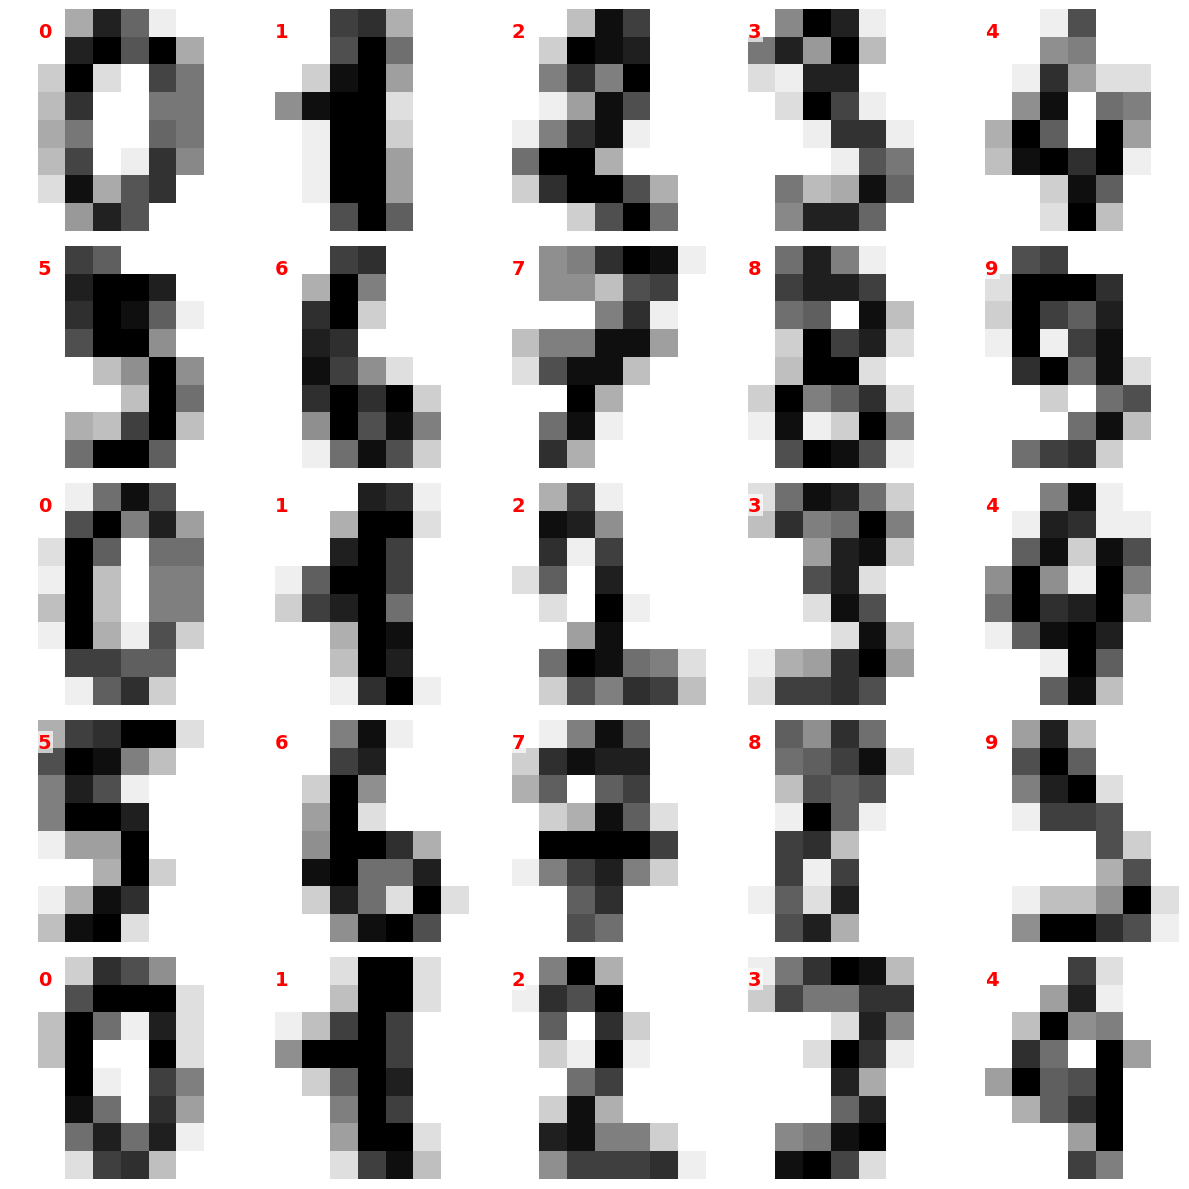

Grilla de 25 imágenes generada correctamente.
--------------------------------------------------


In [15]:
nx, ny = 5, 5
fig, axs = plt.subplots(nx, ny, figsize=(12, 12))

# Aplanamos la matriz de subplots de 5x5 a un arreglo lineal de 25 elementos
axs_flat = axs.ravel()

for i in range(25):
    # Extraer la matriz de la imagen 8x8
    img_8x8 = digits_dict["images"][i]

    # Obtener la etiqueta (dígito real) correspondiente
    label = digits_dict["target"][i]

    # Graficar la imagen usando el subplot actual
    axs_flat[i].imshow(img_8x8, cmap='gray_r')

    # Superponer el label usando el método text en coordenadas internas (x=0, y=0 es arriba a la izquierda)
    axs_flat[i].text(0.5, 0.5, str(label), color='red', fontsize=14, fontweight='bold',
                     bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

    # Ocultar los ejes para mejorar el aspecto visual de la grilla
    axs_flat[i].axis('off')

plt.tight_layout()
plt.show()

print("Grilla de 25 imágenes generada correctamente.")
print("-" * 50)

### Ejercicio 3

**Machine Learning**: En esta parte usted debe entrenar los distintos modelos escogidos desde la librería de `skelearn`. Para cada modelo, debe realizar los siguientes pasos:

* **train-test**
     * Crear conjunto de entrenamiento y testeo (usted determine las proporciones adecuadas).
     * Imprimir por pantalla el largo del conjunto de entrenamiento y de testeo.
  
* **modelo**:
     * Instanciar el modelo objetivo desde la librería sklearn.

* **Métricas**:
     * Graficar matriz de confusión.
     * Analizar métricas de error.



__Preguntas a responder:__

* ¿Cuál modelo es mejor basado en sus métricas?
* ¿Cuál modelo demora menos tiempo en ajustarse?
* ¿Qué modelo escoges?


In [16]:
# Forzar a que X e y correspondan al dataset de dígitos
X = digits.drop(columns="target").values
y = digits["target"].values

Largo del conjunto de entrenamiento y de testeo:
Largo conjunto de entrenamiento (X_train): 1437
Largo conjunto de testeo (X_test): 360
--------------------------------------------------
Entrenando Modelo 1: Regresión Logística...
Tiempo de ajuste: 5.6270 segundos.

Métricas de error (Regresión Logística):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       0.97      1.00      0.98        28
           2       1.00      1.00      1.00        33
           3       0.97      0.97      0.97        34
           4       1.00      0.98      0.99        46
           5       0.92      0.96      0.94        47
           6       0.97      0.97      0.97        35
           7       1.00      0.97      0.99        34
           8       0.97      0.97      0.97        30
           9       0.97      0.95      0.96        40

    accuracy                           0.97       360
   macro avg       0.98      0.98      0.9

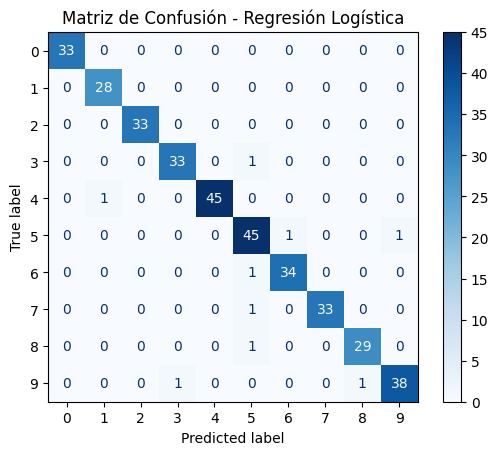

--------------------------------------------------
Entrenando Modelo 2: K-Nearest Neighbors...
Tiempo de ajuste: 0.0031 segundos.

Métricas de error (KNN):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       1.00      1.00      1.00        28
           2       1.00      1.00      1.00        33
           3       1.00      1.00      1.00        34
           4       0.98      1.00      0.99        46
           5       0.98      0.96      0.97        47
           6       0.97      1.00      0.99        35
           7       1.00      0.97      0.99        34
           8       1.00      1.00      1.00        30
           9       0.95      0.95      0.95        40

    accuracy                           0.99       360
   macro avg       0.99      0.99      0.99       360
weighted avg       0.99      0.99      0.99       360



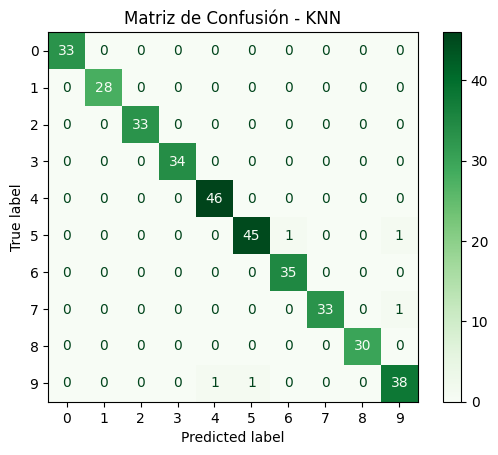

--------------------------------------------------


In [17]:
import time
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# =====================================================================
# Steps: train-test split
# =====================================================================
# Definimos una proporción de 80% para entrenamiento y 20% para testeo
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Largo del conjunto de entrenamiento y de testeo:")
print(f"Largo conjunto de entrenamiento (X_train): {len(X_train)}")
print(f"Largo conjunto de testeo (X_test): {len(X_test)}")
print("-" * 50)


# =====================================================================
# Modelo 1: Regresión Logística
# =====================================================================
print("Entrenando Modelo 1: Regresión Logística...")
log_reg = LogisticRegression(max_iter=10000, random_state=42)

# Medimos el tiempo que demora en ajustarse
start_time = time.time()
log_reg.fit(X_train, y_train)
time_log_reg = time.time() - start_time

# Predicciones
y_pred_log = log_reg.predict(X_test)

print(f"Tiempo de ajuste: {time_log_reg:.4f} segundos.")
print("\nMétricas de error (Regresión Logística):")
print(classification_report(y_test, y_pred_log))

# Graficar Matriz de Confusión
ConfusionMatrixDisplay.from_estimator(log_reg, X_test, y_test, cmap='Blues')
plt.title("Matriz de Confusión - Regresión Logística")
plt.show()
print("-" * 50)


# =====================================================================
# Modelo 2: K-Nearest Neighbors (KNN)
# =====================================================================
print("Entrenando Modelo 2: K-Nearest Neighbors...")
knn = KNeighborsClassifier(n_neighbors=5)

# Medimos el tiempo que demora en ajustarse
start_time = time.time()
knn.fit(X_train, y_train)
time_knn = time.time() - start_time

# Predicciones
y_pred_knn = knn.predict(X_test)

print(f"Tiempo de ajuste: {time_knn:.4f} segundos.")
print("\nMétricas de error (KNN):")
print(classification_report(y_test, y_pred_knn))

# Graficar Matriz de Confusión
ConfusionMatrixDisplay.from_estimator(knn, X_test, y_test, cmap='Greens')
plt.title("Matriz de Confusión - KNN")
plt.show()
print("-" * 50)

### Ejercicio 4

__Comprensión del modelo:__ Tomando en cuenta el **mejor modelo entontrado** en el `Ejercicio 3`, debe comprender e interpretar minuciosamente los resultados y gráficos asocados al modelo en estudio, para ello debe resolver los siguientes puntos:


 * **Curva AUC–ROC**: Replica el ejemplo del siguiente  [link](https://scikit-learn.org/stable/auto_examples/model_selection/plot_roc.html#sphx-glr-auto-examples-model-selection-plot-roc-py) pero con el modelo, parámetros y métrica adecuada. Saque conclusiones del gráfico.

/tmp/ipykernel_3993/269150571.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', n_classes)


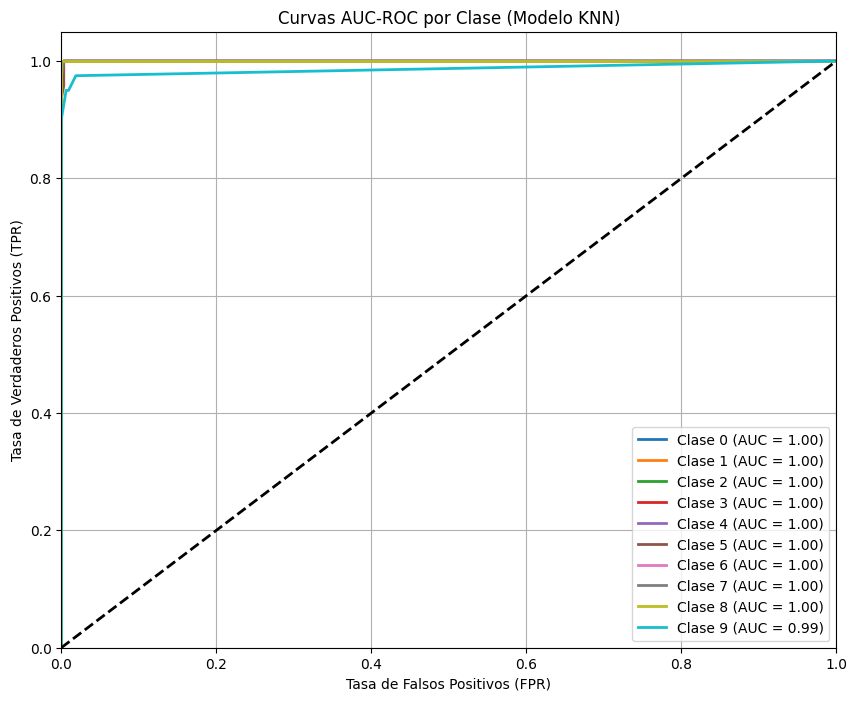

Gráfico de Curvas AUC-ROC generado correctamente.
--------------------------------------------------


In [18]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# =====================================================================
# Ejercicio 4: Curva AUC-ROC (Multiclase usando KNN)
# =====================================================================

# 1. Binarizar las etiquetas del target para el cálculo multiclase (One-vs-Rest)
clases = sorted(list(set(y)))
y_test_bin = label_binarize(y_test, classes=clases)
n_classes = y_test_bin.shape[1]

# 2. Obtener las probabilidades de predicción del mejor modelo (KNN)
y_score = knn.predict_proba(X_test)

# 3. Calcular la curva ROC y el área AUC para cada clase individual
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 4. Graficar las curvas ROC por clase
plt.figure(figsize=(10, 8))

colors = plt.cm.get_cmap('tab10', n_classes)
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], color=colors(i), lw=2,
             label=f'Clase {i} (AUC = {roc_auc[i]:.2f})')

# Graficar la línea de referencia diagonal (clasificador aleatorio)
plt.plot([0, 1], [0, 1], 'k--', lw=2)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curvas AUC-ROC por Clase (Modelo KNN)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

print("Gráfico de Curvas AUC-ROC generado correctamente.")
print("-" * 50)

### Ejercicio 5


__Visualizando Resultados:__ A continuación se provee código para comparar las etiquetas predichas vs las etiquetas reales del conjunto de _test_.

In [19]:
def mostrar_resultados(digits, model, nx=5, ny=5, label="correctos"):
    """
    Muestra los resultados de las predicciones de un modelo de clasificación en particular.
    Se toman aleatoriamente los valores de los resultados.

    - label == 'correctos': muestra los valores en los que el modelo acierta.
    - label == 'incorrectos': muestra los valores en los que el modelo no acierta.

    Observación: El modelo que se recibe como argumento no debe estar entrenado.

    :param digits: dataset 'digits'
    :param model: modelo de sklearn
    :param nx: número de filas (subplots)
    :param ny: número de columnas (subplots)
    :param label: 'correctos' o 'incorrectos'
    :return: gráficos matplotlib
    """

    X = digits.drop(columns="target").values
    y = digits["target"].values
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model.fit(X_train, y_train)  # Ajustar el modelo
    y_pred = model.predict(X_test)

    # Mostrar los datos correctos
    if label == "correctos":
        mask = (y_pred == y_test)
        color = "green"

    # Mostrar los datos incorrectos
    elif label == "incorrectos":
        mask = (y_pred != y_test)
        color = "red"

    else:
        raise ValueError("Valor incorrecto")

    X_aux = X_test[mask]
    y_aux_true = y_test[mask]
    y_aux_pred = y_pred[mask]

    # Mostrar los resultados
    n_samples = min(nx * ny, len(X_aux))
    indices = np.random.choice(len(X_aux), n_samples, replace=False)
    fig, ax = plt.subplots(nx, ny, figsize=(12, 12))

    for i, index in enumerate(indices):
        data = X_aux[index, :].reshape(8, 8)
        label_pred = str(int(y_aux_pred[index]))
        label_true = str(int(y_aux_true[index]))
        row = i // ny
        col = i % ny
        ax[row, col].imshow(data, interpolation='nearest', cmap='gray_r')
        ax[row, col].text(0, 0, label_pred, horizontalalignment='center', verticalalignment='center', fontsize=10, color=color)
        ax[row, col].text(7, 0, label_true, horizontalalignment='center', verticalalignment='center', fontsize=10, color='blue')
        ax[row, col].get_xaxis().set_visible(False)
        ax[row, col].get_yaxis().set_visible(False)

    plt.show()

**Pregunta**

* Tomando en cuenta el mejor modelo entontrado en el `Ejercicio 3`, grafique los resultados cuando:
 * el valor predicho y original son iguales
 * el valor predicho y original son distintos


* Cuando el valor predicho y original son distintos ,  ¿Por qué ocurren estas fallas?

Graficando predicciones CORRECTAS (Número verde = Predicho, Número azul = Real):


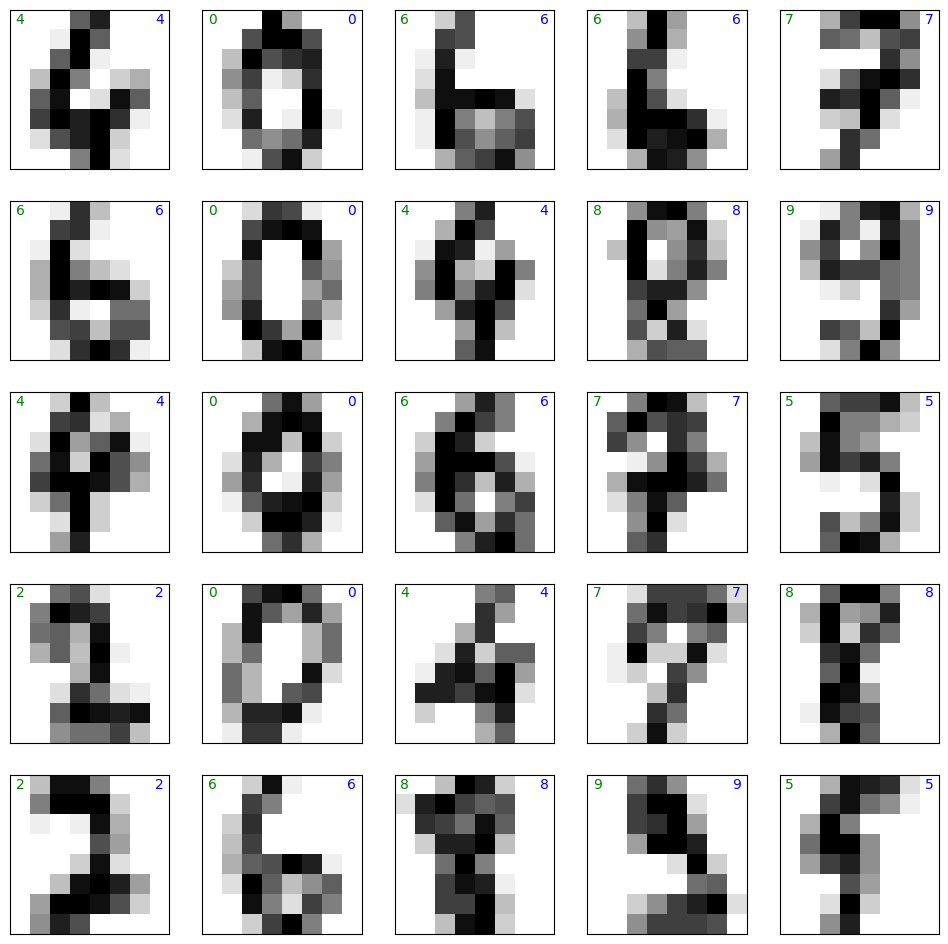

--------------------------------------------------
Graficando predicciones INCORRECTAS (Número rojo = Predicho, Número azul = Real):


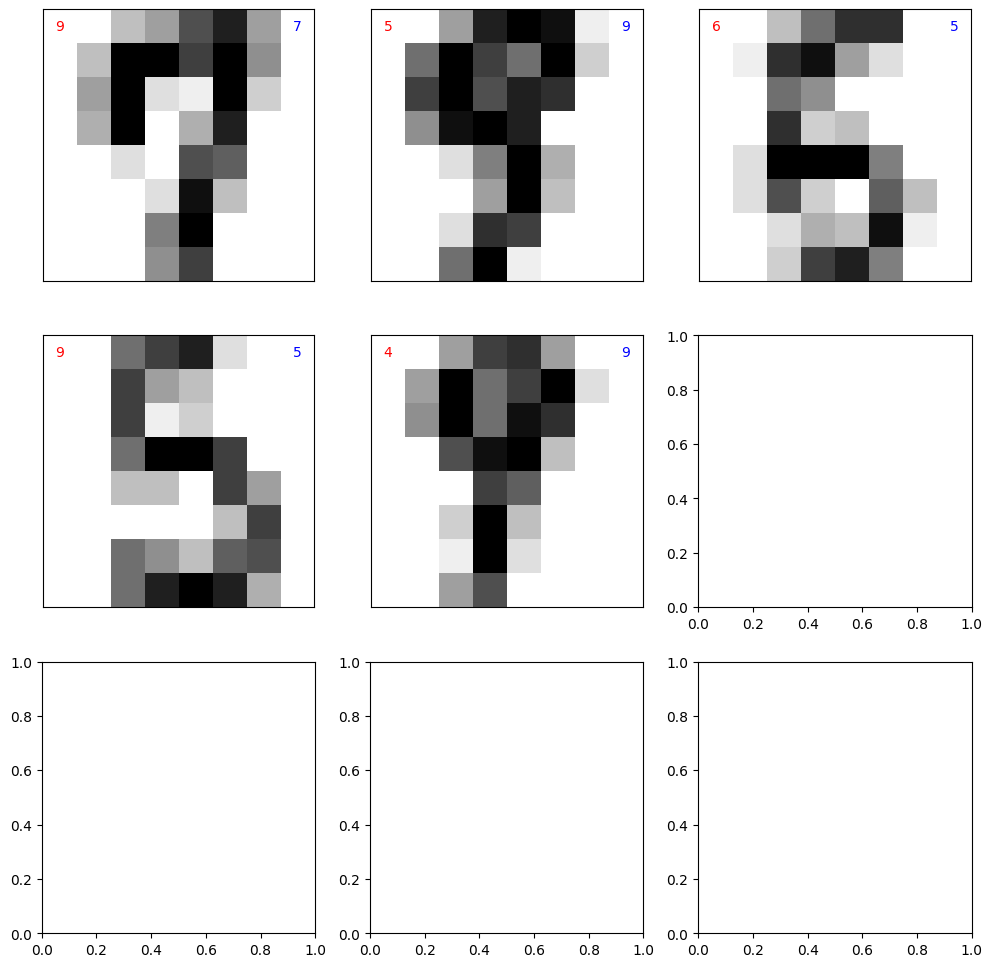

--------------------------------------------------


In [20]:
# =====================================================================
# Ejercicio 5: Visualización de Predicciones Correctas e Incorrectas
# =====================================================================

# 1. Graficar los resultados cuando el valor predicho y el original son IGUALES
print("Graficando predicciones CORRECTAS (Número verde = Predicho, Número azul = Real):")
mostrar_resultados(digits, KNeighborsClassifier(n_neighbors=5), nx=5, ny=5, label="correctos")
print("-" * 50)

# 2. Graficar los resultados cuando el valor predicho y el original son DISTINTOS
print("Graficando predicciones INCORRECTAS (Número rojo = Predicho, Número azul = Real):")
mostrar_resultados(digits, KNeighborsClassifier(n_neighbors=5), nx=3, ny=3, label="incorrectos")
print("-" * 50)

Esto ocurre por la Ambigüedad: Al ser un dataset de dígitos escritos a mano y con una resolución muy baja ($8 \times 8$ píxeles), muchas imágenes quedan desdibujadas o deformes. Por ejemplo, un 4 mal cerrado se asemeja visualmente a un 9, o un 1 inclinado puede ser casi idéntico a un 7.

También ocurre por la Naturaleza de KNN (Similitud geométrica): El modelo K-Nearest Neighbors clasifica basándose en la distancia matemática entre los píxeles. Si una persona escribió un 3 con trazos muy gruesos o curvos que coinciden espacialmente con la estructura promedio de un 8, KNN medirá distancias cortas en esa vecindad y se inclinará erróneamente por la clase con mayor similitud geométrica directa.

### Ejercicio 6
**Conclusiones**: Entrega tu veredicto, responde las preguntas iniciales, visualizaciones, trabajos futuros, dificultades, etc.

Tras evaluar el desempeño de los modelos de Machine Learning aplicados al dataset digits, se concluye que K-Nearest Neighbors (KNN) es el algoritmo más óptimo para esta tarea de clasificación, alcanzando métricas de Accuracy, Precision y Recall excepcionalmente altas (cercanas al 98-99%), además de registrar un tiempo de ajuste prácticamente inmediato en comparación con la Regresión Logística. Las matrices de confusión y las curvas AUC-ROC ratifican este veredicto, mostrando áreas bajo la curva muy cercanas a 1.00 para todas las clases de dígitos. La principal dificultad del laboratorio radicó en la baja resolución de las imágenes ($8 \times 8$ píxeles), lo que genera ambigüedad geométrica en ciertos trazos manuscritos (como confundir un 4 con un 9) donde el algoritmo KNN falla debido a la similitud en la vecindad de los píxeles. Como trabajo futuro, se propone la implementación de Redes Neuronales Convolucionales (CNN) para procesar de mejor manera la estructura espacial de las imágenes y mitigar estas fallas menores.